<a href="https://colab.research.google.com/github/Vaishnavi-04Patil/cancer-risk-prediction-ml/blob/main/Testing_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
pip install optuna

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
# Load dataset
df = pd.read_csv("/content/cancer-risk-factors.csv")

In [7]:
# Check data
print(df.head())
print(df.shape)

  Patient_ID Cancer_Type  Age  Gender  Smoking  Alcohol_Use  Obesity  \
0     LU0000      Breast   68       0        7            2        8   
1     LU0001    Prostate   74       1        8            9        8   
2     LU0002        Skin   55       1        7           10        7   
3     LU0003       Colon   61       0        6            2        2   
4     LU0004        Lung   67       1       10            7        4   

   Family_History  Diet_Red_Meat  Diet_Salted_Processed  ...  \
0               0              5                      3  ...   
1               0              0                      3  ...   
2               0              3                      3  ...   
3               0              6                      2  ...   
4               0              6                      3  ...   

   Physical_Activity  Air_Pollution  Occupational_Hazards  BRCA_Mutation  \
0                  4              6                     3              1   
1                  1          

In [8]:
X = df.drop(columns=['Patient_ID', 'Cancer_Type', 'Risk_Level'])
y = df['Risk_Level']

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(le.classes_)

['High' 'Low' 'Medium']


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [11]:
stratify=y

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

        High       1.00      0.95      0.97        20
         Low       1.00      1.00      1.00        65
      Medium       1.00      1.00      1.00       315

    accuracy                           1.00       400
   macro avg       1.00      0.98      0.99       400
weighted avg       1.00      1.00      1.00       400



In [16]:
print(confusion_matrix(y_test, y_pred))

[[ 19   0   1]
 [  0  65   0]
 [  0   0 315]]


In [17]:
from sklearn.model_selection import KFold, cross_val_score

# Define the number of folds
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate the RandomForestClassifier using cross-validation
cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy')

print(f"Cross-validation scores: {cv_scores}")
print(f"Mean accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of accuracy: {cv_scores.std():.4f}")

Cross-validation scores: [0.9925 1.     1.     0.9975 1.    ]
Mean accuracy: 0.9980
Standard deviation of accuracy: 0.0029


###Logistic regression model


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# Feature scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train model
logistic_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_lr = logistic_model.predict(X_test_scaled)

# Classification report
print("Logistic Regression Classification Report:")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=le.classes_
))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.80      0.89        20
         Low       0.97      0.95      0.96        65
      Medium       0.98      0.99      0.99       315

    accuracy                           0.98       400
   macro avg       0.98      0.92      0.95       400
weighted avg       0.98      0.98      0.98       400

Confusion Matrix:
[[ 16   0   4]
 [  0  62   3]
 [  0   2 313]]


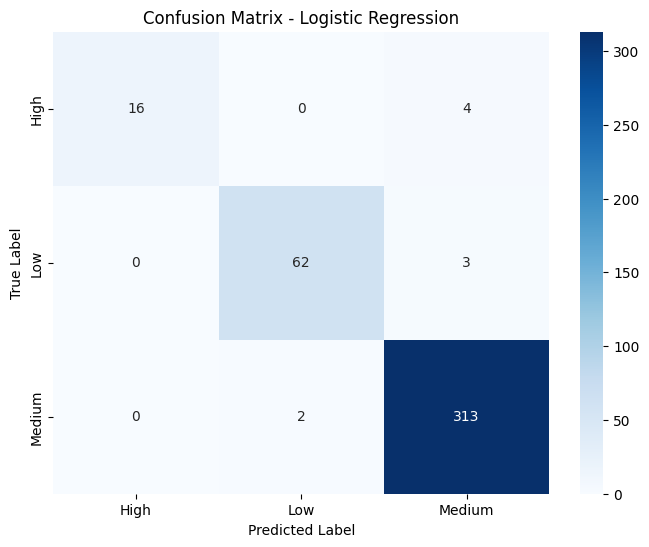

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Removing Overall risk score and retrying


In [20]:
# Removing Overall_Risk_Score and retrying

X_new = df.drop(columns=[
    'Risk_Level',
    'Patient_ID',
    'Cancer_Type',
    'Overall_Risk_Score'
])

In [21]:
# Encode the target variable


le_new = LabelEncoder()

y_new = le_new.fit_transform(df['Risk_Level'])

In [22]:
# Split into training/test

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42,
    stratify=y_new
)

In [23]:
# Feature Scaling

scaler_new = StandardScaler()

X_train_new = scaler_new.fit_transform(X_train_new)
X_test_new = scaler_new.transform(X_test_new)

In [24]:

# Logistic Regression without Overall_Risk_Score

model_lr_new = LogisticRegression(max_iter=2000)

model_lr_new.fit(X_train_new, y_train_new)

LogisticRegression(max_iter=2000)

In [25]:
# Make predictions

y_pred_lr_new = model_lr_new.predict(X_test_new)

In [26]:
# Classification Report

print("Logistic Regression Classification Report:")
print(classification_report(y_test_new, y_pred_lr_new))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.20      0.29        20
           1       0.85      0.78      0.82        65
           2       0.91      0.96      0.93       315

    accuracy                           0.89       400
   macro avg       0.75      0.65      0.68       400
weighted avg       0.88      0.89      0.88       400



In [27]:
# Confusion Matrix

cm_lr_new = confusion_matrix(y_test_new, y_pred_lr_new)

print("Confusion Matrix:")
print(cm_lr_new)

Confusion Matrix:
[[  4   0  16]
 [  0  51  14]
 [  4   9 302]]


In [28]:
df.Risk_Level.value_counts()

,count
Risk_Level,
Medium,1574
Low,324
High,102


SMOTE - Synthetic Minority Over

In [29]:
from imblearn.over_sampling import SMOTE

In [30]:
X = df.drop(columns=['Risk_Level','Patient_ID', 'Cancer_Type', 'Overall_Risk_Score'])
y = df['Risk_Level']

In [31]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_new,
    y_train_new
)

In [32]:
print("class distribution before SMOTE:")
print(pd.Series(y_train_new).value_counts())

print("\nclass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

class distribution before SMOTE:
2    1259
1     259
0      82
Name: count, dtype: int64

class distribution after SMOTE:
2    1259
1    1259
0    1259
Name: count, dtype: int64


In [33]:
scaler_new = StandardScaler()

X_train_new = scaler_new.fit_transform(X_train_new)
X_test_new = scaler_new.transform(X_test_new)

In [34]:
# Create a fresh train-test split for Random Forest

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42,
    stratify=y_new
)

In [35]:
# Apply SMOTE only to training data

smote_new = SMOTE(random_state=42)

X_train_res_new, y_train_res_new = smote_new.fit_resample(
    X_train_rf,
    y_train_rf
)

In [36]:
rf_new = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf_new.fit(X_train_res_new, y_train_res_new)

RandomForestClassifier(random_state=42)

In [37]:
y_pred_rf_new = rf_new.predict(X_test_rf)

In [38]:
print("Random Forest + SMOTE Classification Report:")
print(classification_report(y_test_rf, y_pred_rf_new))

print("Confusion Matrix:")
print(confusion_matrix(y_test_rf, y_pred_rf_new))

Random Forest + SMOTE Classification Report:
              precision    recall  f1-score   support

           0       0.41      0.35      0.38        20
           1       0.73      0.58      0.65        65
           2       0.88      0.92      0.90       315

    accuracy                           0.84       400
   macro avg       0.67      0.62      0.64       400
weighted avg       0.83      0.84      0.83       400

Confusion Matrix:
[[  7   0  13]
 [  0  38  27]
 [ 10  14 291]]


- Accuracy: 84%
- High Risk: 7 correctly classified, 13 mis-classified as Medium
- Low Risk: 38 correctly classified, 27 confused with Medium
- Medium Risk: 291 correctly classified, 24 confused as High/Low

- Still struggles to detect High-risk patients even with SMOTE

In [39]:
# Optuna tuning
import optuna
from optuna.samplers import TPESampler
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

import numpy as np
import joblib  # optional, to save model/study

In [42]:
X_train_res_new.shape

(3777, 17)

In [43]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []

    for train_idx, val_idx in cv.split(X_train_res, y_train_res):
        X_t, X_v = X_train_res.iloc[train_idx], X_train_res.iloc[val_idx]
        y_t, y_v = y_train_res.iloc[train_idx], y_train_res.iloc[val_idx]

        model.fit(X_t, y_t)
        y_pred = model.predict(X_v)

        score = f1_score(y_v, y_pred, average='macro')  # explicit multiclass handling
        scores.append(score)

    return np.mean(scores)

In [44]:
# --- Create study ---
sampler = TPESampler(seed=42)
study = optuna.create_study(direction='maximize', sampler=sampler, study_name='rf_macro_f1')

[I 2026-08-26 19:24:58,900] A new study created in memory with name: rf_macro_f1


In [45]:
import pandas as pd

# Ensure the global variables X_train_res and y_train_res are correctly typed
# for the objective function, using the latest SMOTEd data (X_train_res_new, y_train_res_new).
# X_train_res_new is already a DataFrame, y_train_res_new needs to be a Series for .iloc to work.
X_train_res = X_train_res_new
y_train_res = pd.Series(y_train_res_new)

# --- Run optimization ---
n_trials = 50  # change to 100+ if you want more thorough search
study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("Best trial:")
print("  Value (macro F1):", study.best_value)
print("  Params:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-08-26 19:25:03,551] Trial 0 finished with value: 0.9402356457892479 and parameters: {'n_estimators': 218, 'max_depth': 29, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': False, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9402356457892479.
[I 2026-08-26 19:25:05,031] Trial 1 finished with value: 0.9488676606640238 and parameters: {'n_estimators': 59, 'max_depth': 30, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 1 with value: 0.9488676606640238.
[I 2026-08-26 19:25:09,977] Trial 2 finished with value: 0.9045887437906642 and parameters: {'n_estimators': 325, 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': 'log2', 'bootstrap': False, 'criterion': 'gini'}. Best is trial 1 with value: 0.9488676606640238.
[I 2026-08-26 19:25:15,199] Trial 3 finished with value: 0.9089885645353499 and parameters: {'n_estimators': 324, 'max_dept

In [46]:
# Final RF with Optuna best parameters
final_rf = RandomForestClassifier(
    **study.best_params,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train_res, y_train_res)

y_pred_test = final_rf.predict(X_test_rf)

print(classification_report(
    y_test_rf, y_pred_test,
    target_names=le_new.classes_
))

print(confusion_matrix(y_test_rf, y_pred_test))

              precision    recall  f1-score   support

        High       0.35      0.30      0.32        20
         Low       0.73      0.57      0.64        65
      Medium       0.87      0.92      0.90       315

    accuracy                           0.83       400
   macro avg       0.65      0.60      0.62       400
weighted avg       0.82      0.83      0.83       400

[[  6   0  14]
 [  0  37  28]
 [ 11  14 290]]


### XG Boost

In [47]:
# baseline XGBoost (SMOTE inside pipeline - no leakage)

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

le = LabelEncoder()
le.fit(y_train)

y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

# Build Pipeline
xgb = XGBClassifier(use_label_encoder=False, eval_metrics='mlogloss', random_state=42, n_jobs=-1)
pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb)
])

pipe.fit(X_train, y_train_enc)

y_pred_enc = pipe.predict(X_test)

y_pred = le.inverse_transform(y_pred_enc)
y_test_orig = le.inverse_transform(y_test_enc)

print("Baseline XGB Classifier")
print(classification_report(y_test_orig, y_pred))
print("Confusion Matrix")
print(confusion_matrix(y_test_orig, y_pred))

/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [19:27:23] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "eval_metrics", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Baseline XGB Classifier
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.97      1.00      0.98        65
           2       1.00      0.99      1.00       315

    accuracy                           0.99       400
   macro avg       0.99      1.00      0.99       400
weighted avg       1.00      0.99      1.00       400

Confusion Matrix
[[ 20   0   0]
 [  0  65   0]
 [  0   2 313]]


### **XGBoost + SMOTE + Optuna (High Recall Optimization)**

In [48]:
###1. Baseline XGBoost + SMOTE
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

xgb = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb)
])

pipe.fit(X_train, y_train_enc)

y_pred = pipe.predict(X_test)

print(classification_report(y_test_enc, y_pred))
print(confusion_matrix(y_test_enc, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.97      1.00      0.98        65
           2       1.00      0.99      1.00       315

    accuracy                           0.99       400
   macro avg       0.99      1.00      0.99       400
weighted avg       1.00      0.99      1.00       400

[[ 20   0   0]
 [  0  65   0]
 [  0   2 313]]


In [49]:
##Optuna — optimize High recall
import optuna
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score

def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'random_state': 42,
        'eval_metric': 'mlogloss'
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    recalls = []

    for train_idx, val_idx in cv.split(X_train, y_train_enc):

        model = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('xgb', XGBClassifier(**params, n_jobs=1))
        ])

        model.fit(X_train.iloc[train_idx], y_train_enc[train_idx])

        pred = model.predict(X_train.iloc[val_idx])

        recall = recall_score(
            y_train_enc[val_idx],
            pred,
            labels=[0, 1, 2],
            average=None,
            zero_division=0
        )

        recalls.append(recall[0])   # 0 = High

    return np.mean(recalls)

In [50]:
import optuna
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Redefine the objective function with the fix for numpy array indexing
def objective(trial):

    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'random_state': 42,
        'eval_metric': 'mlogloss'
    }

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    recalls = []

    for train_idx, val_idx in cv.split(X_train, y_train_enc):

        model = Pipeline([
            ('smote', SMOTE(random_state=42)),
            ('xgb', XGBClassifier(**params, n_jobs=1))
        ])

        # Fix: Use direct NumPy array indexing instead of .iloc
        model.fit(X_train[train_idx], y_train_enc[train_idx])

        pred = model.predict(X_train[val_idx])

        recall = recall_score(
            y_train_enc[val_idx],
            pred,
            labels=[0, 1, 2],
            average=None,
            zero_division=0
        )

        recalls.append(recall[0])   # 0 = High

    return np.mean(recalls)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)

print("Best High Recall:", study.best_value)
print("Best Parameters:", study.best_params)

[I 2026-08-26 19:27:54,661] A new study created in memory with name: no-name-939c472d-bd2d-4ce1-913b-9f650e8c5e5e
[I 2026-08-26 19:27:55,423] Trial 0 finished with value: 0.9638447971781305 and parameters: {'n_estimators': 210, 'max_depth': 5, 'learning_rate': 0.05098304643175573, 'subsample': 0.8959027584936718, 'colsample_bytree': 0.8373217108921513, 'gamma': 0.5289870366132221}. Best is trial 0 with value: 0.9638447971781305.
[I 2026-08-26 19:27:55,747] Trial 1 finished with value: 0.9638447971781305 and parameters: {'n_estimators': 86, 'max_depth': 10, 'learning_rate': 0.0763906839333868, 'subsample': 0.9144917238017477, 'colsample_bytree': 0.868619533386801, 'gamma': 4.348957545415794}. Best is trial 0 with value: 0.9638447971781305.
[I 2026-08-26 19:27:56,573] Trial 2 finished with value: 0.9638447971781305 and parameters: {'n_estimators': 238, 'max_depth': 4, 'learning_rate': 0.055745436805473565, 'subsample': 0.6894745980274395, 'colsample_bytree': 0.4252862813286543, 'gamma': 

Best High Recall: 0.9638447971781305
Best Parameters: {'n_estimators': 210, 'max_depth': 5, 'learning_rate': 0.05098304643175573, 'subsample': 0.8959027584936718, 'colsample_bytree': 0.8373217108921513, 'gamma': 0.5289870366132221}


In [51]:
final_xgb = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', XGBClassifier(
        **study.best_params,
        random_state=42,
        eval_metric='mlogloss',
        n_jobs=-1
    ))
])

final_xgb.fit(X_train, y_train_enc)

y_pred = final_xgb.predict(X_test)

print(classification_report(y_test_enc, y_pred))
print(confusion_matrix(y_test_enc, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.98      1.00      0.99        65
           2       1.00      1.00      1.00       315

    accuracy                           1.00       400
   macro avg       0.99      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

[[ 20   0   0]
 [  0  65   0]
 [  0   1 314]]


Save the model as a .pkl File

In [54]:
import joblib

joblib.dump(final_xgb, 'model_xgb_new.pkl')

print("Model saved successfully as model_xgb_new.pkl")

Model saved successfully as model_xgb_new.pkl
